# Image Compression Using Singular Value Decomposition
---
Singular value decomposition (SVD) is an algorithm used to approximate and compress data in large matrices. While it can be used to condense large data sets, its most applicable use is for image compression.

Full SVD:  $ A = U \Sigma V^T $ </br>
Condensed SVD: $ A = \hat{U} \hat{\Sigma} \hat{V^T}$

For this project, I decided to use python instead of MATLAB due to the useful libraries and interactive envionment (jupyter) 

In [ ]:
%matplotlib inline
import cv2 # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import numpy as np

# define the image that is being processed
img = 'egg_car_v2.jpg'
img_data = cv2.imread(img)

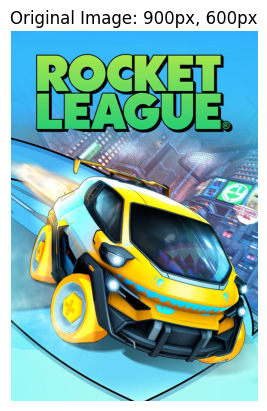

In [ ]:
# Return the current image
def show_image(image, title:str):
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

res = img_data.shape
show_image(img_data, f"Original Image: {res[0]}px, {res[1]}px")

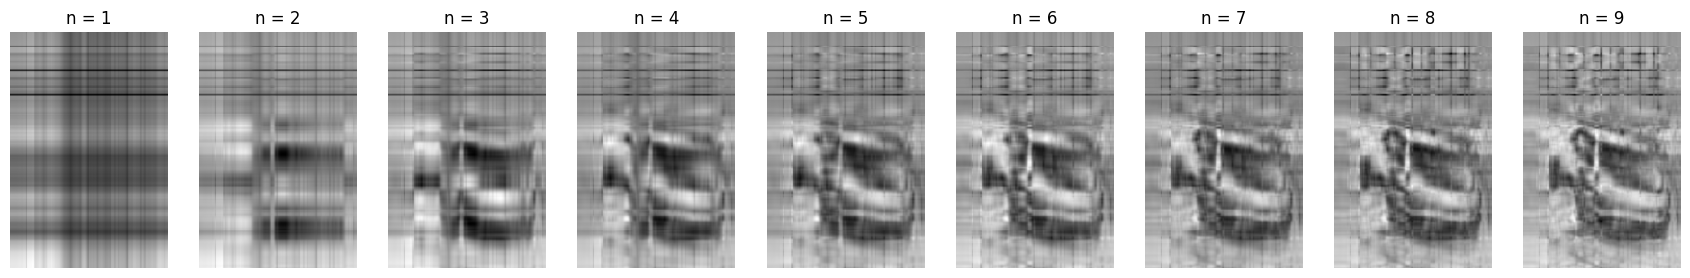

In [19]:
# for grayscale images / output
def svd_gs(image, sv):
    img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    gs_img = np.matrix(U[:,:sv]) * np.diag(S[:sv]) * np.matrix(Vt[:sv,:])
    return gs_img

# showing the effect after adding 5 more singular values each frame
plt.figure(figsize=(24,4))
start, end, step = 1, 10, 1

for i in range(start, end, step):
    plt.subplot(1, (end - start) // step + 1, (i - start) // step + 1)
    img_gs = svd_gs(img, i) # does the svd compression
    plt.imshow(img_gs, cmap='grey')
    plt.title('n = %s' % i)
    plt.axis('off')

plt.show()

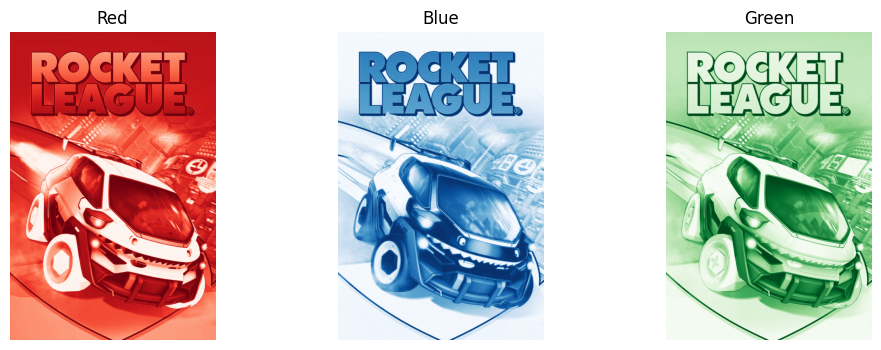

In [13]:
B, G, R = cv2.split(img_data) # splitting color channels

colors = ['Red', 'Blue', 'Green']
matrices = [R, B, G]

plt.figure(figsize=(12, 4))
for i in range(len((colors))):
    plt.subplot(1, 3, i+1)
    plt.title(colors[i])
    plt.imshow(matrices[i],cmap=f'{colors[i]}s_r')
    plt.axis('off')
plt.show()

In [14]:
# Getting the singular values of the matrix S

sing_val_ex = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=False)

np.set_printoptions(precision=1)  # 3 decimal places
print("Values of S:")
print(S)

Values of S:
[1.1e+05 1.8e+04 1.4e+04 1.2e+04 1.0e+04 8.8e+03 8.4e+03 7.4e+03 7.1e+03
 6.9e+03 6.6e+03 6.3e+03 5.8e+03 5.4e+03 5.3e+03 5.0e+03 4.6e+03 4.5e+03
 4.3e+03 4.3e+03 4.0e+03 3.8e+03 3.7e+03 3.6e+03 3.4e+03 3.2e+03 3.2e+03
 3.1e+03 3.0e+03 2.9e+03 2.8e+03 2.8e+03 2.7e+03 2.6e+03 2.5e+03 2.4e+03
 2.3e+03 2.3e+03 2.2e+03 2.2e+03 2.1e+03 2.1e+03 2.1e+03 2.0e+03 2.0e+03
 1.9e+03 1.9e+03 1.9e+03 1.9e+03 1.8e+03 1.8e+03 1.8e+03 1.7e+03 1.7e+03
 1.7e+03 1.6e+03 1.6e+03 1.6e+03 1.6e+03 1.6e+03 1.5e+03 1.5e+03 1.5e+03
 1.5e+03 1.4e+03 1.4e+03 1.4e+03 1.4e+03 1.4e+03 1.3e+03 1.3e+03 1.3e+03
 1.3e+03 1.3e+03 1.3e+03 1.2e+03 1.2e+03 1.2e+03 1.2e+03 1.2e+03 1.2e+03
 1.2e+03 1.1e+03 1.1e+03 1.1e+03 1.1e+03 1.1e+03 1.1e+03 1.1e+03 1.1e+03
 1.0e+03 1.0e+03 1.0e+03 1.0e+03 1.0e+03 1.0e+03 1.0e+03 1.0e+03 9.8e+02
 9.7e+02 9.6e+02 9.5e+02 9.4e+02 9.4e+02 9.2e+02 9.0e+02 9.0e+02 8.9e+02
 8.9e+02 8.8e+02 8.8e+02 8.7e+02 8.5e+02 8.5e+02 8.4e+02 8.4e+02 8.3e+02
 8.2e+02 8.2e+02 8.1e+02 8.0e+02 7.9e+

In [15]:
%%time
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=True)

CPU times: user 1.77 s, sys: 1.98 ms, total: 1.78 s
Wall time: 118 ms


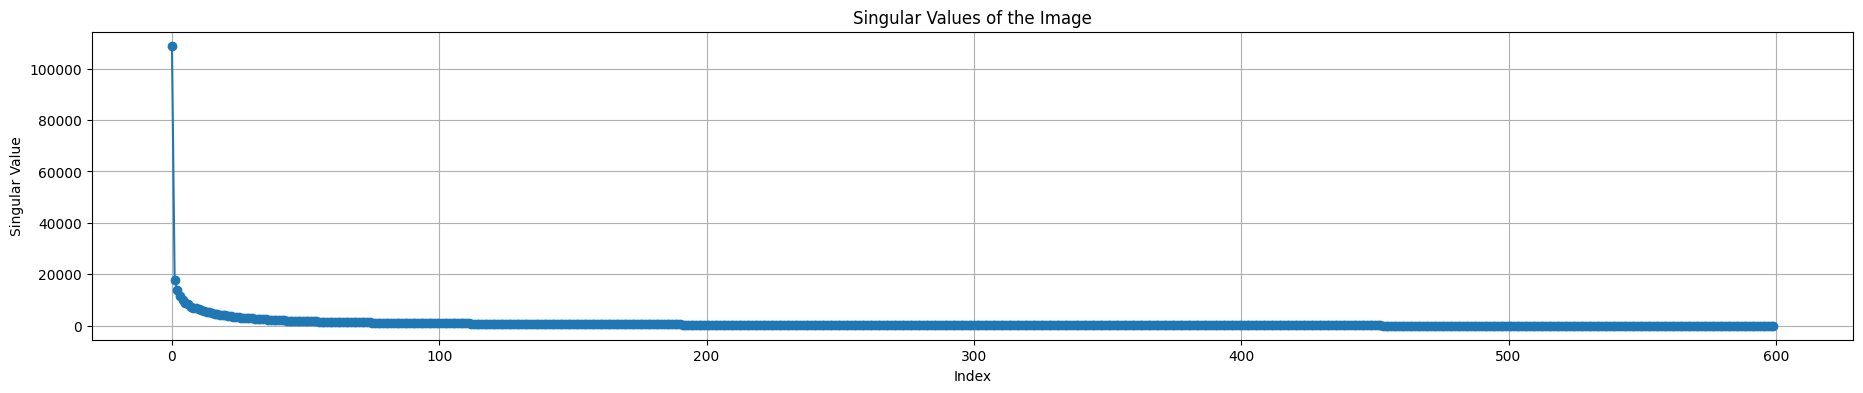

In [16]:
plt.figure(figsize=(50,4))
plt.subplot(1, 2, 1)
plt.plot(S, marker='o')
plt.title("Singular Values of the Image")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)

plt.show()

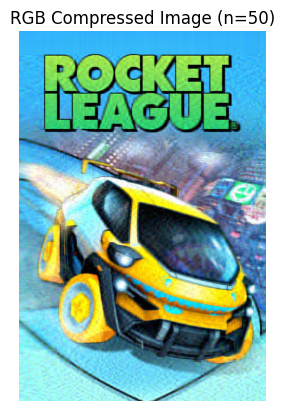

CPU times: user 20.1 s, sys: 30.2 ms, total: 20.2 s
Wall time: 1.53 s


In [21]:
%%time
def svd_color(image, sv):
    B, G, R = cv2.split(image)

    U_b, S_b, Vt_b = np.linalg.svd(B, full_matrices=False)
    U_g, S_g, Vt_g = np.linalg.svd(G, full_matrices=False)
    U_r, S_r, Vt_r = np.linalg.svd(R, full_matrices=False)

    R_comp = np.matrix(U_r[:, :sv]) * np.diag(S_r[:sv]) * np.matrix(Vt_r[:sv, :])
    G_comp = np.matrix(U_g[:, :sv]) * np.diag(S_g[:sv]) * np.matrix(Vt_g[:sv, :])
    B_comp = np.matrix(U_b[:, :sv]) * np.diag(S_b[:sv]) * np.matrix(Vt_b[:sv, :])

    comp_full = cv2.merge([np.clip(R_comp, 1, 255), np.clip(G_comp, 1, 255), np.clip(B_comp, 1, 255)])
    comp_full = comp_full.astype(np.uint8)

    plt.imshow(comp_full)
    plt.title(f'RGB Compressed Image (n={sv})')
    plt.axis('off')
    plt.show()

svd_color(img_data, 50)